In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
pd.options.display.float_format = '{:.6f}'.format  # 保留6位小数
import os
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


# 固定 Python 与数值库的并行/哈希
os.environ["PYTHONHASHSEED"] = "42"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

import random
import numpy as np
import torch

def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)      # 即便你现在用 CPU，写上也无害
    # 若用 GPU：强制确定性
    torch.use_deterministic_algorithms(True)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

import warnings
warnings.filterwarnings("ignore")

plt.rcParams["font.family"] = "serif"
plt.rcParams["font.serif"] = ["Times New Roman"]
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

plt.rcParams['axes.unicode_minus'] = False    # 解决负号显示问题

# PATH_WEIGHT_CSV = "../data/城市货运量.xlsx"  # 285城市总货运量表（含 2013-2022（2023））
PATH_FEATURE_CSV = "../data/城市特征表.xlsx"  # 285城市特征表（含 2013-2022（2023））
PATH_EDGE_CSV = "../data/2023年城市边特征表.xlsx"  # 边表（含 Source/Target/Weight（车次）/距离（公里））

# 1.数据读取

In [17]:
#城市货运量及预测值
# weight_df = pd.read_excel(PATH_WEIGHT_CSV,sheet_name="城市货运量")
# weight_df.columns = weight_df.columns.astype(str).str.strip()
feature_df = pd.read_excel(PATH_FEATURE_CSV,sheet_name="特征表")
# 边特征表（车次流量、距离）
edge_df = pd.read_excel(PATH_EDGE_CSV,sheet_name="边原始特征")

In [22]:
rename_map = {
    "年份": "year",
    "行政区划代码": "admin_code",
    "city": "city_name",
    "公路货运量(万吨)": "road_freight_volume_10kt",
    "地区生产总值（亿元）": "gdp_billion_rmb",
    "第一产业增加值（亿元）": "primary_industry_value_billion_rmb",
    "第二产业增加值（亿元）": "secondary_industry_value_billion_rmb",
    "第三产业增加值（亿元）": "tertiary_industry_value_billion_rmb",
    "人口规模(万人)": "population_10k",
    "平均坡度": "mean_slope_deg",
    "所辖县级以上城市个数": "num_subordinate_counties",
    "平均海拔": "mean_elevation_m",
    "Authority": "authority_index"
}

feature_df = feature_df.rename(columns=rename_map)


In [23]:
feature_df

,year,admin_code,city_name,road_freight_volume_10kt,gdp_billion_rmb,primary_industry_value_billion_rmb,secondary_industry_value_billion_rmb,tertiary_industry_value_billion_rmb,population_10k,mean_slope_deg,num_subordinate_counties,mean_elevation_m,authority_index
0,2013,110000,北京市,24651,19500.560000,159.800000,4168.300000,16806.500000,2125.000000,13.322497,1,364.889380,0.089384
1,2014,110000,北京市,25416,21330.830000,159.200000,4433.000000,18333.900000,2171.000000,13.322497,1,364.889380,0.089384
2,2015,110000,北京市,19044,23014.590000,140.400000,4419.800000,20218.900000,2188.000000,13.322497,1,364.889380,0.089384
3,2016,110000,北京市,19972,25669.130000,129.800000,4665.800000,22245.700000,2195.000000,13.322497,1,364.889380,0.089384
4,2017,110000,北京市,19374,28014.940000,121.900000,5049.400000,24711.700000,2194.000000,13.322497,1,364.889380,0.089384
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2845,2018,650500,哈密市,4251,536.608500,40.590000,322.350000,173.670000,55.940000,7.038947,3,1197.812992,0.018531
2846,2019,650500,哈密市,4209,605.000000,41.269000,341.148400,222.397900,55.760000,7.038947,3,1197.812992,0.018531
2847,2020,650500,哈密市,2015,608.000000,44.910000,352.600000,210.400000,67.340000,7.038947,3,1197.812992,0.018531
2848,2021,650500,哈密市,3223,727.000000,46.019100,451.975900,229.005000,67.000000,7.038947,3,1197.812992,0.018531


In [24]:
feature_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2850 entries, 0 to 2849
Data columns (total 13 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   year                                  2850 non-null   int64  
 1   admin_code                            2850 non-null   int64  
 2   city_name                             2850 non-null   object 
 3   road_freight_volume_10kt              2850 non-null   int64  
 4   gdp_billion_rmb                       2850 non-null   float64
 5   primary_industry_value_billion_rmb    2850 non-null   float64
 6   secondary_industry_value_billion_rmb  2850 non-null   float64
 7   tertiary_industry_value_billion_rmb   2850 non-null   float64
 8   population_10k                        2850 non-null   float64
 9   mean_slope_deg                        2850 non-null   float64
 10  num_subordinate_counties              2850 non-null   int64  
 11  mean_elevation_m 

In [25]:
feature_df.columns

Index(['year', 'admin_code', 'city_name', 'road_freight_volume_10kt',
       'gdp_billion_rmb', 'primary_industry_value_billion_rmb',
       'secondary_industry_value_billion_rmb',
       'tertiary_industry_value_billion_rmb', 'population_10k',
       'mean_slope_deg', 'num_subordinate_counties', 'mean_elevation_m',
       'authority_index'],
      dtype='object')

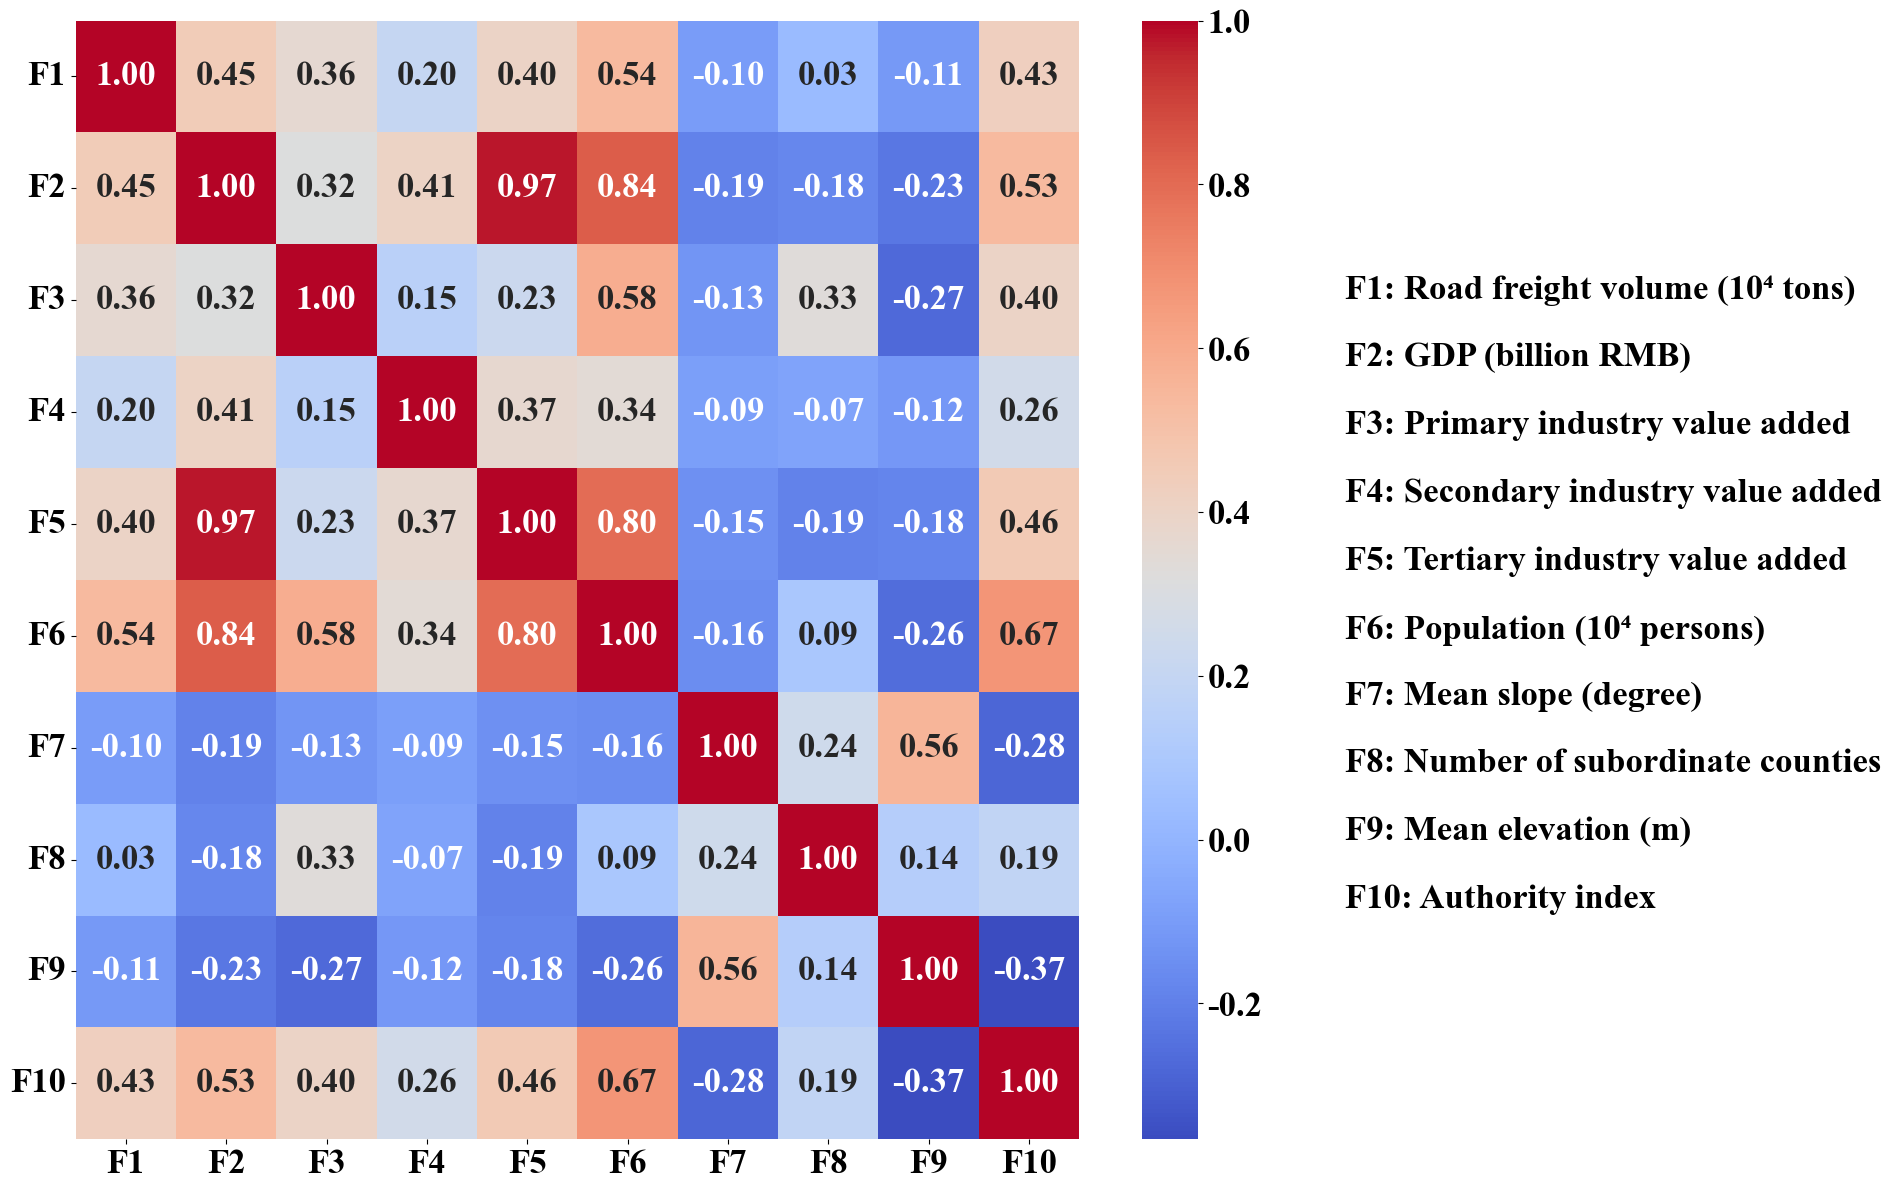

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =========================
# 1. 原始变量列表
# =========================
vars_corr = [
    'road_freight_volume_10kt',
    'gdp_billion_rmb', 
    'primary_industry_value_billion_rmb',
    'secondary_industry_value_billion_rmb',
    'tertiary_industry_value_billion_rmb',
    'population_10k',
    'mean_slope_deg', 
    'num_subordinate_counties', 
    'mean_elevation_m',
    'authority_index'
]

# =========================
# 2. 序号标签（F1, F2, ..., F10）
# =========================
feat_labels = [f"F{i+1}" for i in range(len(vars_corr))]

# =========================
# 3. 序号含义说明（右侧文字）
# =========================
label_mapping = {
    "F1":  "Road freight volume (10⁴ tons)",
    "F2":  "GDP (billion RMB)",
    "F3":  "Primary industry value added",
    "F4":  "Secondary industry value added",
    "F5":  "Tertiary industry value added",
    "F6":  "Population (10⁴ persons)",
    "F7":  "Mean slope (degree)",
    "F8":  "Number of subordinate counties",
    "F9":  "Mean elevation (m)",
    "F10": "Authority index"
}

legend_text = "\n".join([f"{k}: {v}" for k, v in label_mapping.items()])

# =========================
# 4. 相关矩阵
# =========================
corr = feature_df[vars_corr].corr()

# =========================
# 5. 绘图（留右侧空间）
# =========================
fig, ax = plt.subplots(figsize=(18, 12))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    annot_kws={"size":25},
    xticklabels=feat_labels,
    yticklabels=feat_labels,
    ax=ax
)

ax.set_xticklabels(feat_labels, fontsize=25)
ax.set_yticklabels(feat_labels, fontsize=25, rotation=0)

cbar = ax.collections[0].colorbar
cbar.ax.tick_params(labelsize=25)

for label in cbar.ax.get_yticklabels():
    label.set_fontweight("bold")
    
# =========================
# 6. 右侧添加“F编号说明”
# =========================
plt.gcf().text(
    0.75,        # 横向位置（越大越靠右）
    0.50,        # 纵向居中
    legend_text,
    fontsize=25,
    va="center",
    ha="left",
    linespacing=2.6

)

# =========================
# 7. 布局与保存
# =========================
plt.tight_layout(rect=[0, 0, 0.75, 1])  # 给右侧说明留空间
plt.savefig(
    "../img/Fig_TechnicalValidation_Correlation_Matrix_Flabels.png",
    dpi=1000,
    bbox_inches="tight"
)
plt.show()


# 2.模型训练

In [57]:
feature_df.columns

Index(['year', 'admin_code', 'city_name', 'road_freight_volume_10kt',
       'gdp_billion_rmb', 'primary_industry_value_billion_rmb',
       'secondary_industry_value_billion_rmb',
       'tertiary_industry_value_billion_rmb', 'population_10k',
       'mean_slope_deg', 'num_subordinate_counties', 'mean_elevation_m',
       'authority_index'],
      dtype='object')

In [58]:
#货运量差异太极端：训练的目标（货运量）做对数变换 y 使用 log1p(y)

#滞后项 lag_freight 也 log 变换（保持尺度一致）

#预测后要反变换：预测值 = expm1(pred_log)

#交叉验证全部改为 log 模型，然后计算真实误差

df_model = feature_df.copy()
df_model = df_model.sort_values(['city_name', 'year']).reset_index(drop=True)

# === 1. 构造 log-transform 特征 ===

# 原货运量的 log 标签
df_model['log_freight'] = np.log1p(df_model['road_freight_volume_10kt'])

# 滞后项
df_model['lag_freight'] = df_model.groupby('city_name')['log_freight'].shift(1)

# 经济增长特征
df_model['GDP_growth'] = df_model.groupby('city_name')['gdp_billion_rmb'].pct_change()
df_model['pop_growth'] = df_model.groupby('city_name')['population_10k'].pct_change()

# 第二、三产业占比
gdp = df_model['gdp_billion_rmb']
df_model['sec_ratio'] = np.where(gdp > 0, df_model['secondary_industry_value_billion_rmb'] / gdp, 0)
df_model['ter_ratio'] = np.where(gdp > 0, df_model['tertiary_industry_value_billion_rmb'] / gdp, 0)

# 删除无法生成 lag 和增长率的行
df_model_clean = df_model.dropna(subset=['lag_freight', 'GDP_growth', 'pop_growth']).reset_index(drop=True)

target_col = 'log_freight'

feature_cols = [
    'year',
    'admin_code',
    'gdp_billion_rmb',
    'primary_industry_value_billion_rmb',
    'secondary_industry_value_billion_rmb',
    'tertiary_industry_value_billion_rmb',
    'population_10k',
    'mean_slope_deg',
    'num_subordinate_counties',
    'mean_elevation_m',
    'authority_index',
    # log 序列特征
    'lag_freight',
    'GDP_growth',
    'pop_growth',
    'sec_ratio',
    'ter_ratio'
]

train_years = list(range(2014, 2022))
test_year = 2022

train_df = df_model_clean[df_model_clean['year'].isin(train_years)]
test_df  = df_model_clean[df_model_clean['year'] == test_year]

X_train = train_df[feature_cols]
y_train = train_df[target_col]

X_test = test_df[feature_cols]
y_test_log = test_df[target_col]         # log 标签
y_test_real = test_df['road_freight_volume_10kt']  # 用于真实误差


In [59]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# ==========================
# TimeSeriesSplit 设置 统一的时间序列交叉验证设置
# ==========================
tscv = TimeSeriesSplit(n_splits=8)

# ==========================
# 模型字典
# ==========================
models = {
    "XGBoost": XGBRegressor(
        n_estimators=600,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        random_state=42
    ),
    "RandomForest": RandomForestRegressor(
        n_estimators=500,
        random_state=42,
        n_jobs=-1
    ),
    "DecisionTree": DecisionTreeRegressor(
        max_depth=None,
        random_state=42
    ),
    "LinearRegression": LinearRegression()

}

results_cv = {}
results_test = {}

print("=== 不同模型的 TimeSeriesSplit 验证 与 2022 测试表现 ===\n")

# ==========================
# 多模型循环
# ==========================
for name, model in models.items():
    print(f"====== 模型：{name} ======")

    cv_r2, cv_rmse, cv_mae, cv_mape = [], [], [], []

    fold = 1
    for tr, val in tscv.split(X_train):
        X_tr, X_val = X_train.iloc[tr], X_train.iloc[val]
        y_tr, y_val = y_train.iloc[tr], y_train.iloc[val]

        # 训练
        model.fit(X_tr, y_tr)

        # 验证集 log 预测
        y_val_pred_log = model.predict(X_val)

        # 反变换
        y_val_real = np.expm1(y_val)
        y_val_pred_real = np.expm1(y_val_pred_log)

        r2   = r2_score(y_val_real, y_val_pred_real)
        rmse = np.sqrt(mean_squared_error(y_val_real, y_val_pred_real))
        mae  = mean_absolute_error(y_val_real, y_val_pred_real)
        mape = np.mean(np.abs((y_val_real - y_val_pred_real) / y_val_real)) * 100

        cv_r2.append(r2)
        cv_rmse.append(rmse)
        cv_mae.append(mae)
        cv_mape.append(mape)

        print(f"Fold {fold}: R²={r2:.4f}, RMSE={rmse:.1f}, MAE={mae:.1f}, MAPE={mape:.2f}%")
        fold += 1

    # === 交叉验证结果 ===
    print(f"\n--- {name} 的 TimeSeriesSplit 平均表现 ---")
    print(f"R²   : {np.mean(cv_r2):.4f} ± {np.std(cv_r2):.4f}")
    print(f"RMSE : {np.mean(cv_rmse):.1f}")
    print(f"MAE  : {np.mean(cv_mae):.1f}")
    print(f"MAPE : {np.mean(cv_mape):.2f}%\n")

    # 存储
    results_cv[name] = {
        "R2_mean": np.mean(cv_r2),
        "R2_std": np.std(cv_r2),
        "RMSE": np.mean(cv_rmse),
        "MAE": np.mean(cv_mae),
        "MAPE": np.mean(cv_mape)
    }

    # === 训练完整模型，测试 2022 ===
    model.fit(X_train, y_train)
    y_pred_log_test = model.predict(X_test)
    y_pred_real_test = np.expm1(y_pred_log_test)

    r2_test   = r2_score(y_test_real, y_pred_real_test)
    rmse_test = np.sqrt(mean_squared_error(y_test_real, y_pred_real_test))
    mae_test  = mean_absolute_error(y_test_real, y_pred_real_test)
    mape_test = np.mean(np.abs((y_test_real - y_pred_real_test) / y_test_real)) * 100

    print(f"=== {name} 在 2022 年测试集上的表现 ===")
    print(f"R²   : {r2_test:.4f}")
    print(f"RMSE : {rmse_test:.1f}")
    print(f"MAE  : {mae_test:.1f}")
    print(f"MAPE : {mape_test:.2f}%\n")

    results_test[name] = {
        "R2": r2_test,
        "RMSE": rmse_test,
        "MAE": mae_test,
        "MAPE": mape_test
    }
    # # ==========================
    # # 画：2022 真实 vs 预测散点图（每个模型一张）
    # # ==========================
    # plt.figure(figsize=(7, 6))
    # plt.scatter(y_test_real, y_pred_real_test, alpha=0.6, edgecolors="k", s=45)
    
    # # 1:1 参考线（用真实与预测的共同范围）
    # min_val = min(y_test_real.min(), y_pred_real_test.min())
    # max_val = max(y_test_real.max(), y_pred_real_test.max())
    # plt.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="1:1 reference")
    
    # plt.xlabel("Observed freight volume in 2022 ($10^4$ tons)")
    # plt.ylabel("Predicted freight volume in 2022 ($10^4$ tons)")
    # plt.title(f"{name}: Observed vs Predicted in 2022 ($R^2$={r2_test:.3f})")
    
    # plt.legend()
    # plt.grid(True)
    # plt.tight_layout()
    # plt.show()
    results_test[name]["y_pred"] = y_pred_real_test.copy()

print("\n===== 各模型测试集表现（2022）对比 =====")
for name, m in results_test.items():
    print(f"{name}: R²={m['R2']:.4f}, RMSE={m['RMSE']:.1f}, MAE={m['MAE']:.1f}, MAPE={m['MAPE']:.2f}%")

=== 不同模型的 TimeSeriesSplit 验证 与 2022 测试表现 ===

====== 模型：XGBoost ======
Fold 1: R²=0.6809, RMSE=5676.2, MAE=3284.2, MAPE=38.58%
Fold 2: R²=0.8459, RMSE=3382.2, MAE=1954.6, MAPE=20.78%
Fold 3: R²=0.1106, RMSE=27304.2, MAE=5586.4, MAPE=27.43%
Fold 4: R²=0.8844, RMSE=2979.4, MAE=1791.6, MAPE=36.83%
Fold 5: R²=0.5026, RMSE=6974.4, MAE=2562.3, MAPE=25.56%
Fold 6: R²=0.8820, RMSE=2863.4, MAE=1690.4, MAPE=16.63%
Fold 7: R²=0.6981, RMSE=10911.5, MAE=4860.9, MAPE=26.92%
Fold 8: R²=0.8843, RMSE=3370.9, MAE=1745.7, MAPE=18.37%

--- XGBoost 的 TimeSeriesSplit 平均表现 ---
R²   : 0.6861 ± 0.2519
RMSE : 7932.8
MAE  : 2934.5
MAPE : 26.39%

=== XGBoost 在 2022 年测试集上的表现 ===
R²   : 0.8764
RMSE : 4543.4
MAE  : 2325.6
MAPE : 33.93%

====== 模型：RandomForest ======
Fold 1: R²=0.7450, RMSE=5073.8, MAE=2814.2, MAPE=30.08%
Fold 2: R²=0.8625, RMSE=3194.4, MAE=1771.4, MAPE=18.52%
Fold 3: R²=0.0986, RMSE=27488.0, MAE=5337.0, MAPE=24.02%
Fold 4: R²=0.9002, RMSE=2767.4, MAE=1589.2, MAPE=29.03%
Fold 5: R²=0.5201, RMSE=6850.

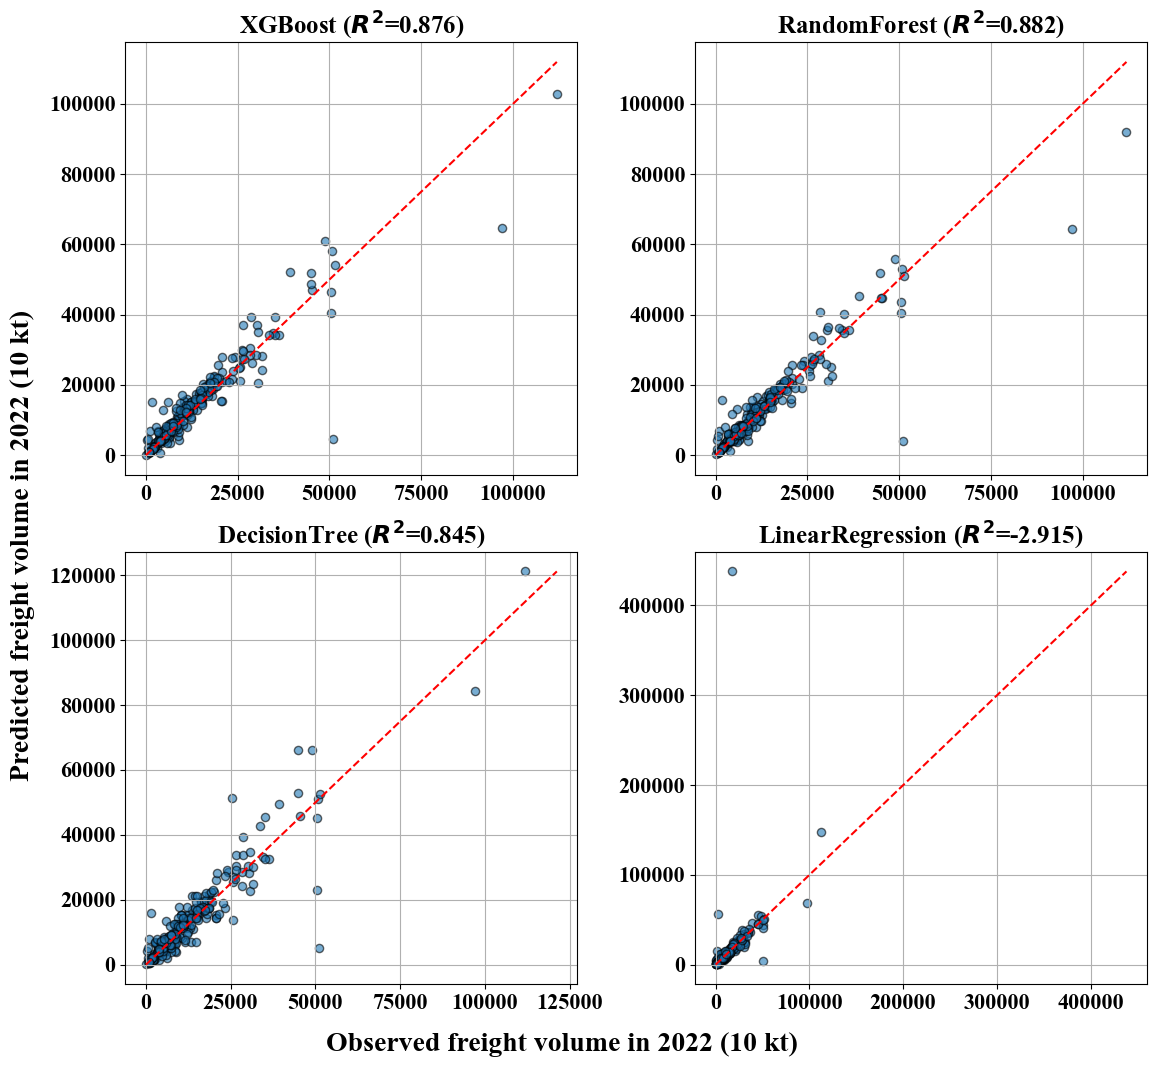

In [65]:
import matplotlib.pyplot as plt

# ==========================
# 选择要展示的模型顺序
# ==========================
model_order = ["XGBoost", "RandomForest", "DecisionTree", "LinearRegression"]

fig, axes = plt.subplots(2, 2, figsize=(12, 11))
axes = axes.flatten()

# ==========================
# 逐个模型画图
# ==========================
for ax, model_name in zip(axes, model_order):
    
    y_pred = results_test[model_name]["y_pred"]
    r2     = results_test[model_name]["R2"]
    rmse   = results_test[model_name]["RMSE"]

    min_val = min(y_test_real.min(), y_pred.min())
    max_val = max(y_test_real.max(), y_pred.max())

    # 散点
    ax.scatter(
        y_test_real,
        y_pred,
        alpha=0.6,
        edgecolors="k",
        s=35
    )

    # 1:1 参考线
    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        "r--",
        linewidth=1.5
    )

    # 标题
    ax.set_title(
        f"{model_name} ($R^2$={r2:.3f})",
        fontsize=18
    )

    ax.grid(True)
    # x y轴刻度字号
    ax.tick_params(axis="both", labelsize=16)


# ==========================
# 公共坐标轴标签
# ==========================
fig.text(0.5, 0.04, "Observed freight volume in 2022 (10 kt)", ha="center", fontsize=20)
fig.text(0.04, 0.5, "Predicted freight volume in 2022 (10 kt)", va="center", rotation="vertical", fontsize=20)


plt.tight_layout(rect=[0.06, 0.06, 1, 1])

# ==========================
# 保存高分辨率图片（论文用）
# ==========================
plt.savefig("../img/Fig_TechnicalValidation_4models_scatter_2022", dpi=1000, bbox_inches="tight")

plt.show()


In [10]:
# read data to be filled(2023) 
feature_df23 = pd.read_excel(PATH_FEATURE_CSV,sheet_name="2013-2023")
feature_df23

,年份,行政区划代码,city,公路货运量(万吨),地区生产总值（亿元）,第一产业增加值（亿元）,第二产业增加值（亿元）,第三产业增加值（亿元）,人口规模(万人),平均坡度,所辖县级以上城市个数,平均海拔,Authority
0,2013,110000,北京市,24651.000000,19500.560000,159.800000,4168.300000,16806.500000,2125.000000,13.322497,1,364.889380,0.089384
1,2014,110000,北京市,25416.000000,21330.830000,159.200000,4433.000000,18333.900000,2171.000000,13.322497,1,364.889380,0.089384
2,2015,110000,北京市,19044.000000,23014.590000,140.400000,4419.800000,20218.900000,2188.000000,13.322497,1,364.889380,0.089384
3,2016,110000,北京市,19972.000000,25669.130000,129.800000,4665.800000,22245.700000,2195.000000,13.322497,1,364.889380,0.089384
4,2017,110000,北京市,19374.000000,28014.940000,121.900000,5049.400000,24711.700000,2194.000000,13.322497,1,364.889380,0.089384
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3130,2019,650500,哈密市,4209.000000,605.000000,41.269000,341.148400,222.397900,55.760000,7.038947,3,1197.812992,0.018531
3131,2020,650500,哈密市,2015.000000,608.000000,44.910000,352.600000,210.400000,67.340000,7.038947,3,1197.812992,0.018531
3132,2021,650500,哈密市,3223.000000,727.000000,46.019100,451.975900,229.005000,67.000000,7.038947,3,1197.812992,0.018531
3133,2022,650500,哈密市,3755.000000,869.000000,46.143900,577.885000,244.884200,67.340000,7.038947,3,1197.812992,0.018531


In [11]:
feature_df23.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3135 entries, 0 to 3134
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   年份           3135 non-null   int64  
 1   行政区划代码       3135 non-null   int64  
 2   city         3135 non-null   object 
 3   公路货运量(万吨)    3009 non-null   float64
 4   地区生产总值（亿元）   3135 non-null   float64
 5   第一产业增加值（亿元）  3135 non-null   float64
 6   第二产业增加值（亿元）  3135 non-null   float64
 7   第三产业增加值（亿元）  3135 non-null   float64
 8   人口规模(万人)     3135 non-null   float64
 9   平均坡度         3135 non-null   float64
 10  所辖县级以上城市个数   3135 non-null   int64  
 11  平均海拔         3135 non-null   float64
 12  Authority    3135 non-null   float64
dtypes: float64(9), int64(3), object(1)
memory usage: 318.5+ KB


In [12]:

# ===========================
# 假设你已有的训练数据 df_model_clean（2014–2022）

df_all = feature_df23.sort_values(["city", "年份"]).reset_index(drop=True)

# ======================
# 1. 构造时间序列特征（对 2023 同样有效）
# ======================

df_all["lag_freight"] = df_all.groupby("city")["公路货运量(万吨)"].shift(1)
df_all["GDP_growth"]  = df_all.groupby("city")["地区生产总值（亿元）"].pct_change()
df_all["pop_growth"]  = df_all.groupby("city")["人口规模(万人)"].pct_change()

gdp = df_all["地区生产总值（亿元）"]
df_all["sec_ratio"] = np.where(gdp > 0, df_all["第二产业增加值（亿元）"] / gdp, 0.0)
df_all["ter_ratio"] = np.where(gdp > 0, df_all["第三产业增加值（亿元）"] / gdp, 0.0)

# ======================
# 2. log-transform（训练目标）
# ======================
df_all["log_freight"] = np.log1p(df_all["公路货运量(万吨)"])

# 训练集：2014–2022
train_df = df_all[(df_all["年份"] >= 2014) & (df_all["年份"] <= 2022)]
test_2023 = df_all[df_all["年份"] == 2023]

feature_cols = [
    '年份',
    '行政区划代码',
    '地区生产总值（亿元）',
    '第一产业增加值（亿元）',
    '第二产业增加值（亿元）',
    '第三产业增加值（亿元）',
    '人口规模(万人)',
    '平均坡度',
    '所辖县级以上城市个数',
    '平均海拔',
    'Authority',
    'lag_freight',
    'GDP_growth',
    'pop_growth',
    'sec_ratio',
    'ter_ratio'
]

X_train = train_df.dropna(subset=["log_freight"])[feature_cols]
y_train = train_df.dropna(subset=["log_freight"])["log_freight"]

X_2023 = test_2023[feature_cols]

# ======================
# 3. 训练最终模型（与之前一致）
# ======================
model = models["RandomForest"]

model.fit(X_train, y_train)

# ======================
# 4. 预测 2023 年缺失货运量（log → 反变换）
# ======================
y_pred_2023 = model.predict(X_2023)
y_pred_2023_real = np.expm1(y_pred_2023)

# 写回 2023 表
test_2023["补齐_公路货运量(万吨)"] = y_pred_2023_real

# 输出缺失城市预测结果
missing_pred = test_2023[test_2023["公路货运量(万吨)"].isna()][
    ["city", "补齐_公路货运量(万吨)"]
]

print("=== 2023 年缺失城市预测结果 ===")
print(missing_pred)

# 若需合并回 feature_df23：
feature_df23_filled = feature_df23.copy()
feature_df23_filled = feature_df23_filled.merge(
    missing_pred,
    on="city",
    how="left"
)

# 最终货运量（已有的不变，缺失的用模型填补）
feature_df23_filled["最终_公路货运量(万吨)"] = feature_df23_filled[
    "公路货运量(万吨)"
].fillna(feature_df23_filled["补齐_公路货运量(万吨)"])

print("=== 最终补齐后的 2023 数据 ===")
print(feature_df23_filled.head())


=== 2023 年缺失城市预测结果 ===
      city  补齐_公路货运量(万吨)
21     三明市   6350.851601
32    三门峡市   6302.374748
87     中卫市   6128.759799
109    临汾市  17194.135775
153    丽水市   5151.476953
...    ...           ...
3013  马鞍山市   4939.283691
3024  驻马店市  13658.845869
3035   鸡西市   1767.019540
3068   鹰潭市   6723.760173
3134   龙岩市  10068.026374

[126 rows x 2 columns]
=== 最终补齐后的 2023 数据 ===
     年份  行政区划代码 city    公路货运量(万吨)   地区生产总值（亿元）  第一产业增加值（亿元）  第二产业增加值（亿元）  \
0  2013  110000  北京市 24651.000000 19500.560000   159.800000  4168.300000   
1  2014  110000  北京市 25416.000000 21330.830000   159.200000  4433.000000   
2  2015  110000  北京市 19044.000000 23014.590000   140.400000  4419.800000   
3  2016  110000  北京市 19972.000000 25669.130000   129.800000  4665.800000   
4  2017  110000  北京市 19374.000000 28014.940000   121.900000  5049.400000   

   第三产业增加值（亿元）    人口规模(万人)      平均坡度  所辖县级以上城市个数       平均海拔  Authority  \
0 16806.500000 2125.000000 13.322497           1 364.889380   0.089384   
1 18333.900000 2171.00000

In [16]:
feature_df23_filled.tail(30)

,年份,行政区划代码,city,公路货运量(万吨),地区生产总值（亿元）,第一产业增加值（亿元）,第二产业增加值（亿元）,第三产业增加值（亿元）,人口规模(万人),平均坡度,所辖县级以上城市个数,平均海拔,Authority,补齐_公路货运量(万吨),最终_公路货运量(万吨)
3105,2016,650100,乌鲁木齐市,14938.000000,2458.976600,28.135300,704.083700,1726.757600,351.960000,13.710938,2,1650.540043,0.016645,4042.688737,14938.000000
3106,2017,650100,乌鲁木齐市,17145.000000,2743.820000,25.002100,823.798100,1881.845300,350.400000,13.710938,2,1650.540043,0.016645,4042.688737,17145.000000
3107,2018,650100,乌鲁木齐市,19500.000000,3099.765900,25.787100,950.955500,2123.023000,350.580000,13.710938,2,1650.540043,0.016645,4042.688737,19500.000000
3108,2019,650100,乌鲁木齐市,19303.000000,3413.000000,27.699800,906.138200,2479.420700,355.200000,13.710938,2,1650.540043,0.016645,4042.688737,19303.000000
3109,2020,650100,乌鲁木齐市,9243.000000,3337.000000,27.050000,907.890000,2402.380000,405.000000,13.710938,2,1650.540043,0.016645,4042.688737,9243.000000
3110,2021,650100,乌鲁木齐市,4711.000000,3692.000000,28.059200,1040.036400,2623.904400,404.843629,13.710938,2,1650.540043,0.016645,4042.688737,4711.000000
3111,2022,650100,乌鲁木齐市,8898.000000,3893.000000,31.144000,1133.252300,2728.603700,408.240000,13.710938,2,1650.540043,0.016645,4042.688737,8898.000000
3112,2023,650100,乌鲁木齐市,NaN,4168.000000,33.120000,1146.740000,2988.600000,408.000000,13.710938,2,1650.540043,0.016645,4042.688737,4042.688737
3113,2013,650400,吐鲁番市,1684.000000,267.200000,39.777200,158.576300,62.539200,64.290000,8.373775,3,1030.264818,0.000843,1341.945750,1684.000000
3114,2014,650400,吐鲁番市,1684.000000,277.500000,42.700000,167.100000,67.600000,65.310000,8.373775,3,1030.264818,0.000843,1341.945750,1684.000000


In [22]:
feature_df23_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3135 entries, 0 to 3134
Data columns (total 15 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   年份            3135 non-null   int64  
 1   行政区划代码        3135 non-null   int64  
 2   city          3135 non-null   object 
 3   公路货运量(万吨)     3009 non-null   float64
 4   地区生产总值（亿元）    3135 non-null   float64
 5   第一产业增加值（亿元）   3135 non-null   float64
 6   第二产业增加值（亿元）   3135 non-null   float64
 7   第三产业增加值（亿元）   3135 non-null   float64
 8   人口规模(万人)      3135 non-null   float64
 9   平均坡度          3135 non-null   float64
 10  所辖县级以上城市个数    3135 non-null   int64  
 11  平均海拔          3135 non-null   float64
 12  Authority     3135 non-null   float64
 13  补齐_公路货运量(万吨)  1386 non-null   float64
 14  最终_公路货运量(万吨)  3135 non-null   float64
dtypes: float64(11), int64(3), object(1)
memory usage: 367.5+ KB


In [21]:
feature_filled = feature_df23_filled.drop(columns=["补齐_公路货运量(万吨)"])
feature_filled["公路货运量(万吨)"] = feature_filled["最终_公路货运量(万吨)"]
feature_filled = feature_filled.drop(columns=["最终_公路货运量(万吨)"])
feature_filled

,年份,行政区划代码,city,公路货运量(万吨),地区生产总值（亿元）,第一产业增加值（亿元）,第二产业增加值（亿元）,第三产业增加值（亿元）,人口规模(万人),平均坡度,所辖县级以上城市个数,平均海拔,Authority
0,2013,110000,北京市,24651.000000,19500.560000,159.800000,4168.300000,16806.500000,2125.000000,13.322497,1,364.889380,0.089384
1,2014,110000,北京市,25416.000000,21330.830000,159.200000,4433.000000,18333.900000,2171.000000,13.322497,1,364.889380,0.089384
2,2015,110000,北京市,19044.000000,23014.590000,140.400000,4419.800000,20218.900000,2188.000000,13.322497,1,364.889380,0.089384
3,2016,110000,北京市,19972.000000,25669.130000,129.800000,4665.800000,22245.700000,2195.000000,13.322497,1,364.889380,0.089384
4,2017,110000,北京市,19374.000000,28014.940000,121.900000,5049.400000,24711.700000,2194.000000,13.322497,1,364.889380,0.089384
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3130,2019,650500,哈密市,4209.000000,605.000000,41.269000,341.148400,222.397900,55.760000,7.038947,3,1197.812992,0.018531
3131,2020,650500,哈密市,2015.000000,608.000000,44.910000,352.600000,210.400000,67.340000,7.038947,3,1197.812992,0.018531
3132,2021,650500,哈密市,3223.000000,727.000000,46.019100,451.975900,229.005000,67.000000,7.038947,3,1197.812992,0.018531
3133,2022,650500,哈密市,3755.000000,869.000000,46.143900,577.885000,244.884200,67.340000,7.038947,3,1197.812992,0.018531


In [23]:
feature_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3135 entries, 0 to 3134
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   年份           3135 non-null   int64  
 1   行政区划代码       3135 non-null   int64  
 2   city         3135 non-null   object 
 3   公路货运量(万吨)    3135 non-null   float64
 4   地区生产总值（亿元）   3135 non-null   float64
 5   第一产业增加值（亿元）  3135 non-null   float64
 6   第二产业增加值（亿元）  3135 non-null   float64
 7   第三产业增加值（亿元）  3135 non-null   float64
 8   人口规模(万人)     3135 non-null   float64
 9   平均坡度         3135 non-null   float64
 10  所辖县级以上城市个数   3135 non-null   int64  
 11  平均海拔         3135 non-null   float64
 12  Authority    3135 non-null   float64
dtypes: float64(9), int64(3), object(1)
memory usage: 318.5+ KB


In [24]:
df = feature_filled.copy()

# 提取省级代码（例如 110000 → 11, 130100 → 13）
df["省级代码"] = df["行政区划代码"] // 10000

# 按“年份 + 省级代码”分组求和
pro_fre = df.groupby(["年份", "省级代码"])["公路货运量(万吨)"].sum().reset_index()

print(pro_fre)


       年份  省级代码     公路货运量(万吨)
0    2013    11  24651.000000
1    2013    12  31985.000000
2    2013    13 224320.000000
3    2013    14  79844.000000
4    2013    15 122442.000000
..    ...   ...           ...
314  2023    61 133777.040850
315  2023    62  63694.362384
316  2023    63   2450.945419
317  2023    64  36159.245291
318  2023    65   9288.082138

[319 rows x 3 columns]


In [38]:
province_map = {
    11: "北京市",
    12: "天津市",
    13: "河北省",
    14: "山西省",
    15: "内蒙古自治区",
    21: "辽宁省",
    22: "吉林省",
    23: "黑龙江省",
    31: "上海市",
    32: "江苏省",
    33: "浙江省",
    34: "安徽省",
    35: "福建省",
    36: "江西省",
    37: "山东省",
    41: "河南省",
    42: "湖北省",
    43: "湖南省",
    44: "广东省",
    45: "广西壮族自治区",
    46: "海南省",
    50: "重庆市",
    51: "四川省",
    52: "贵州省",
    53: "云南省",
    54: "西藏自治区",
    61: "陕西省",
    62: "甘肃省",
    63: "青海省",
    64: "宁夏回族自治区",
    65: "新疆维吾尔自治区"
}

# 增加省份列
pro_fre["省份"] = pro_fre["省级代码"].map(province_map)

pro_fre


,年份,省级代码,公路货运量(万吨),省份
0,2013,11,24651.000000,北京市
1,2013,12,31985.000000,天津市
2,2013,13,224320.000000,河北省
3,2013,14,79844.000000,山西省
4,2013,15,122442.000000,内蒙古自治区
...,...,...,...,...
314,2023,61,133777.040850,陕西省
315,2023,62,63694.362384,甘肃省
316,2023,63,2450.945419,青海省
317,2023,64,36159.245291,宁夏回族自治区


In [30]:
est_sum_province = pro_fre.tail(29)
est_sum_province

,年份,省级代码,公路货运量(万吨),省份
290,2023,11,19399.300000,北京市
291,2023,12,33741.860000,天津市
292,2023,13,208788.943616,河北省
293,2023,14,110524.130165,山西省
294,2023,15,110874.251274,内蒙古自治区
295,2023,21,149077.085821,辽宁省
296,2023,22,46741.000000,吉林省
297,2023,23,40984.019540,黑龙江省
298,2023,31,50436.270000,上海市
299,2023,32,183486.000000,江苏省


In [45]:
est_sum_province.to_csv("../data/2023地级市货运量估计填充版00.csv", index=False, encoding="utf_8_sig")

# 校准和分解2023货运量

In [72]:
adjust = pd.read_csv("../data/2023地级市货运量估计填充版.csv")
adjust["相对误差比"] = pd.to_numeric(
    adjust["相对误差比"].astype(str).str.replace("%", "", regex=False).str.strip(),
    errors="coerce")

In [73]:
adjust.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   年份             29 non-null     int64  
 1   省级代码           29 non-null     int64  
 2   省份             29 non-null     object 
 3   省级统计货运量        29 non-null     int64  
 4   省级估计公路货运量(万吨)  29 non-null     int64  
 5   绝对误差           29 non-null     float64
 6   相对误差比          29 non-null     float64
 7   校准系数           29 non-null     float64
dtypes: float64(3), int64(4), object(1)
memory usage: 1.9+ KB


In [89]:
adjust

,年份,省级代码,省份,省级统计货运量,省级估计公路货运量(万吨),绝对误差,相对误差比,校准系数
0,2023,11,北京市,19399,19399,-0.300000,0.000000,0.999985
1,2023,12,天津市,33742,33742,0.140000,0.000000,1.000004
2,2023,13,河北省,217492,208789,8703.060000,4.000000,1.041684
3,2023,14,山西省,121751,110524,11226.870000,9.220000,1.101578
4,2023,15,内蒙古自治区,146372,110874,35497.750000,24.250000,1.320162
5,2023,21,辽宁省,153305,149077,4227.910000,2.760000,1.028361
6,2023,22,吉林省,49034,46741,2293.000000,4.680000,1.049058
7,2023,23,黑龙江省,41619,40984,634.980000,1.530000,1.015493
8,2023,31,上海市,50436,50436,-0.270000,0.000000,0.999995
9,2023,32,江苏省,183485,183486,-1.000000,0.000000,0.999995


In [75]:
# =========================
# 1) 市级表：提取省级代码
# =========================
df = feature_filled[feature_filled["年份"] == 2023].copy()
df["省级代码"] = df["行政区划代码"] // 10000

# 统一确保预测值非负（防止权重异常）
df["公路货运量(万吨)"] = pd.to_numeric(df["公路货运量(万吨)"], errors="coerce").clip(lower=0)

# =========================
# 2) 分出两类省份：可校准 (<30) 与需分解 (>=30)
# =========================
calib_prov = adjust.loc[adjust["相对误差比"] < 30, ["省级代码", "校准系数"]]
decomp_prov = adjust.loc[adjust["相对误差比"] >= 30, ["省级代码", "省级统计货运量"]]

# =========================
# 3) 先做 <30% 省份的“省级校准”
# =========================
df = df.merge(calib_prov, on="省级代码", how="left")
df["校准后_公路货运量(万吨)"] = df["公路货运量(万吨)"] * df["校准系数"].fillna(1.0)

# =========================
# 4) 对 >=30% 省份做“省级分解”
#    权重优先用市级预测货运量；如果总和为0，用GDP；再不行均分
# =========================
df = df.merge(decomp_prov, on="省级代码", how="left", suffixes=("", "_prov"))

def decompose_one_province(sub):
    Y = sub["省级统计货运量"].iloc[0]  # 该省统计总量
    if pd.isna(Y):
        # 不是需要分解的省，直接返回 NaN
        sub["分解后_公路货运量(万吨)"] = np.nan
        return sub

    # ① 用预测货运量做权重
    w_base = sub["公路货运量(万吨)"].fillna(0).clip(lower=0)
    s = w_base.sum()

    if s > 0:
        w = w_base / s
    else:
        # ② 兜底：用GDP做权重
        gdp = pd.to_numeric(sub["地区生产总值（亿元）"], errors="coerce").fillna(0).clip(lower=0)
        sg = gdp.sum()
        if sg > 0:
            w = gdp / sg
        else:
            # ③ 再兜底：均分
            w = np.ones(len(sub)) / len(sub)

    sub["分解后_公路货运量(万吨)"] = Y * w
    return sub

df = df.groupby("省级代码", group_keys=False).apply(decompose_one_province)

# =========================
# 5) 最终结果：<30% 用校准后；>=30% 用分解后
# =========================
# 标记哪些省需要分解
need_decomp_set = set(decomp_prov["省级代码"].dropna().astype(int).tolist())

df["最终_公路货运量(万吨)"] = np.where(
    df["省级代码"].isin(need_decomp_set),
    df["分解后_公路货运量(万吨)"],
    df["校准后_公路货运量(万吨)"]
)

# =========================
# 6) 检查：>=30% 省份分解后省级汇总应≈省级统计货运量
# =========================
check_decomp = (
    df[df["省级代码"].isin(need_decomp_set)]
    .groupby("省级代码")["最终_公路货运量(万吨)"].sum()
    .reset_index()
    .merge(adjust[["省级代码", "省级统计货运量"]], on="省级代码", how="left")
)
check_decomp["差值"] = check_decomp["最终_公路货运量(万吨)"] - check_decomp["省级统计货运量"]
print(check_decomp)

# 最终 df 就是带有“最终_公路货运量(万吨)”的 2023 市级表


   省级代码  最终_公路货运量(万吨)  省级统计货运量       差值
0    63  17983.000000    17983 0.000000
1    65  82742.000000    82742 0.000000


In [76]:
df

,年份,行政区划代码,city,公路货运量(万吨),地区生产总值（亿元）,第一产业增加值（亿元）,第二产业增加值（亿元）,第三产业增加值（亿元）,人口规模(万人),平均坡度,所辖县级以上城市个数,平均海拔,Authority,省级代码,校准系数,校准后_公路货运量(万吨),省级统计货运量,分解后_公路货运量(万吨),最终_公路货运量(万吨)
0,2023,110000,北京市,19399.300000,43761.000000,105.500000,6525.600000,37129.600000,2186.000000,13.322497,1,364.889380,0.089384,11,0.999985,19399.000009,NaN,NaN,19399.000009
1,2023,120000,天津市,33741.860000,16737.000000,268.500000,5982.620000,10486.200000,1364.000000,2.680783,1,19.992284,0.097031,12,1.000004,33741.999995,NaN,NaN,33741.999995
2,2023,130100,石家庄市,54000.000000,7534.000000,576.900000,2309.200000,4648.100000,1123.000000,9.034856,15,253.471211,0.101642,13,1.041684,56250.909648,NaN,NaN,56250.909648
3,2023,130200,唐山市,44769.900000,9133.000000,655.200000,4660.000000,3818.000000,772.000000,4.986676,8,60.522860,0.077785,13,1.041684,46636.066664,NaN,NaN,46636.066664
4,2023,130300,秦皇岛市,7165.630000,2001.000000,259.950000,640.410000,1100.650000,311.000000,11.307825,4,233.388820,0.065279,13,1.041684,7464.318624,NaN,NaN,7464.318624
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
280,2023,640400,固原市,6415.000000,437.000000,80.510000,92.330000,264.280000,115.000000,13.932894,5,1899.119156,0.053100,64,1.246182,7994.257421,NaN,NaN,7994.257421
281,2023,640500,中卫市,6128.759799,591.000000,81.880000,269.510000,239.390000,108.000000,9.596981,3,1651.778187,0.054385,64,1.246182,7637.550040,NaN,NaN,7637.550040
282,2023,650100,乌鲁木齐市,4042.688737,4168.000000,33.120000,1146.740000,2988.600000,408.000000,13.710938,2,1650.540043,0.016645,65,NaN,4042.688737,82742.000000,36013.909712,36013.909712
283,2023,650400,吐鲁番市,1341.945750,588.000000,80.130000,317.800000,190.180000,69.000000,8.373775,3,1030.264818,0.000843,65,NaN,1341.945750,82742.000000,11954.596610,11954.596610


In [81]:
df[["city","最终_公路货运量(万吨)"]].to_csv("../data/2023地级市货运量最终值.csv", index=False, encoding="utf_8_sig")


# 将以上23年数据填充到13-23统计年鉴数据得到 dataset1.2013-2023地级市总货运量.xlsx